In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# configuration
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

df_data = pd.read_csv(r"C:\Users\merry b\Downloads\farmer_advisor_dataset.csv")

print("Aperçu des 5 premières lignes :")
display(df_data.head())

print("\nDimensions du dataset :", df_data.shape)
print("\nTypes des colonnes :")
print(df_data.dtypes)

Aperçu des 5 premières lignes :


,Farm_ID,Soil_pH,Soil_Moisture,Temperature_C,Rainfall_mm,Crop_Type,Fertilizer_Usage_kg,Pesticide_Usage_kg,Crop_Yield_ton,Sustainability_Score
0,1,7.073643,49.145359,26.668157,227.890912,Wheat,131.692844,2.958215,1.576920,51.913649
1,2,6.236931,21.496115,29.325342,244.017493,Soybean,136.370492,19.204770,3.824686,47.159077
2,3,5.922335,19.469042,17.666414,141.110521,Corn,99.725210,11.041066,1.133198,50.148418
3,4,6.845120,27.974234,17.188722,156.785663,Wheat,194.832396,8.806271,8.870540,89.764557
4,5,6.934171,33.637679,23.603899,77.859362,Corn,57.271267,3.747553,8.779317,51.033941



Dimensions du dataset : (10000, 10)

Types des colonnes :
Farm_ID                   int64
Soil_pH                 float64
Soil_Moisture           float64
Temperature_C           float64
Rainfall_mm             float64
Crop_Type                object
Fertilizer_Usage_kg     float64
Pesticide_Usage_kg      float64
Crop_Yield_ton          float64
Sustainability_Score    float64
dtype: object


In [9]:
print("\nValeurs manquantes par colonne :")
print(df_data.isna().sum())


Valeurs manquantes par colonne :
Farm_ID                 0
Soil_pH                 0
Soil_Moisture           0
Temperature_C           0
Rainfall_mm             0
Crop_Type               0
Fertilizer_Usage_kg     0
Pesticide_Usage_kg      0
Crop_Yield_ton          0
Sustainability_Score    0
dtype: int64


In [10]:
print("\nStatistiques générales :")
display(df_data.describe())


Statistiques générales :


,Farm_ID,Soil_pH,Soil_Moisture,Temperature_C,Rainfall_mm,Fertilizer_Usage_kg,Pesticide_Usage_kg,Crop_Yield_ton,Sustainability_Score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,6.499494,29.988655,25.027475,174.969854,125.212701,10.521074,5.489634,50.213200
std,2886.89568,0.574181,11.493376,5.769509,72.860989,43.132645,5.535558,2.608809,28.667146
min,1.00000,5.500021,10.002907,15.000186,50.031967,50.007543,1.001370,1.000323,0.003672
25%,2500.75000,6.003992,20.027802,20.078612,111.786631,87.945625,5.675684,3.218402,25.974568
50%,5000.50000,6.495380,29.862527,24.955117,174.468002,125.188012,10.619785,5.490626,50.234210
75%,7500.25000,6.993481,40.052369,30.053313,237.812507,162.619398,15.330758,7.740585,74.938267
max,10000.00000,7.499762,49.994713,34.999673,299.986192,199.991631,19.999099,9.999638,99.994545


In [6]:
sample_simple = df_data.sample(n=1000, random_state=42)

In [7]:
sample_simple.describe()

,Farm_ID,Soil_pH,Soil_Moisture,Temperature_C,Rainfall_mm,Fertilizer_Usage_kg,Pesticide_Usage_kg,Crop_Yield_ton,Sustainability_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4998.385000,6.481684,30.191233,24.978051,172.377113,124.440650,10.878460,5.443727,49.854478
std,2924.440593,0.572183,11.322087,5.815400,71.947509,43.563207,5.465884,2.592529,29.127769
min,1.000000,5.502277,10.032575,15.022407,50.076617,50.268308,1.004706,1.005271,0.092056
25%,2408.000000,5.968833,20.600456,20.061587,109.219577,87.364157,6.110407,3.314508,24.790848
50%,5093.000000,6.495144,30.259868,24.746933,171.057908,123.157633,10.969881,5.330754,49.048776
75%,7593.750000,6.983540,40.019316,30.121818,232.846145,161.763202,15.639987,7.647116,75.193950
max,9994.000000,7.499551,49.984187,34.982058,299.986192,199.947671,19.999099,9.972597,99.856351


In [8]:
# Colonne utilisée pour les grappes
cluster_column = 'Crop_Type'

# Obtenir les grappes uniques
clusters = df_data[cluster_column].unique()

# Mélanger les grappes
np.random.seed(42)
np.random.shuffle(clusters)

# Initialisation de l'échantillon
sampled_data = pd.DataFrame()

# Ajouter les grappes jusqu'à atteindre n=1000
for cluster in clusters:
    cluster_data = df_data[df_data[cluster_column] == cluster]
    sampled_data = pd.concat([sampled_data, cluster_data])
    if len(sampled_data) >= 1000:
        break

# Réduire à exactement 1000 lignes si nécessaire
sampled_data = sampled_data.sample(n=1000, random_state=42).reset_index(drop=True)

print("Taille de l'échantillon:", len(sampled_data))

Taille de l'échantillon: 1000


In [9]:
sampled_data.describe()

,Farm_ID,Soil_pH,Soil_Moisture,Temperature_C,Rainfall_mm,Fertilizer_Usage_kg,Pesticide_Usage_kg,Crop_Yield_ton,Sustainability_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4991.390000,6.494502,30.282431,25.260721,176.535277,123.983031,10.416649,5.358877,51.337320
std,2878.785555,0.581041,11.553575,5.693890,71.566997,42.777683,5.516695,2.592285,28.316427
min,28.000000,5.501289,10.008659,15.005768,50.032798,50.215772,1.046018,1.001689,0.054479
25%,2478.750000,5.999315,20.107263,20.519131,116.588738,86.927315,5.762362,3.097330,27.804963
50%,4968.000000,6.494914,30.482726,25.464528,176.594621,122.521892,10.195890,5.347317,52.770491
75%,7369.250000,6.991682,40.577872,30.005664,236.248703,161.453128,15.185742,7.555484,75.573952
max,9993.000000,7.499761,49.863964,34.997529,299.592321,199.827724,19.987809,9.997556,99.804008


In [10]:
from sklearn.model_selection import train_test_split

n = 1000
test_size = 1 - (n / len(df_data))

sample_stratified, _ = train_test_split(
    df_data,
    test_size=test_size,
    stratify=df_data['Crop_Type'],
    random_state=42
)

In [11]:
sample_stratified.describe()

,Farm_ID,Soil_pH,Soil_Moisture,Temperature_C,Rainfall_mm,Fertilizer_Usage_kg,Pesticide_Usage_kg,Crop_Yield_ton,Sustainability_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4912.071000,6.502391,30.569265,25.097607,173.982839,126.923064,10.492188,5.495650,50.220951
std,2877.202269,0.579956,11.352305,5.827812,71.817219,43.300988,5.636923,2.603251,28.723906
min,4.000000,5.502366,10.081676,15.001917,50.505990,50.030998,1.012835,1.000323,0.003672
25%,2483.500000,6.011476,20.839353,20.064738,110.726906,89.532075,5.461477,3.258345,25.998435
50%,4889.000000,6.490562,30.259335,25.099801,174.142474,128.811746,10.710808,5.470332,49.742774
75%,7389.750000,7.020038,40.892686,30.163003,234.868781,164.630817,15.452832,7.732078,75.202177
max,9987.000000,7.499762,49.980437,34.991066,299.971369,199.616076,19.985008,9.998343,99.982898


In [12]:
# Pour le dataset complet
print("Dataset complet :")
print(df_data['Crop_Type'].value_counts(normalize=True))

# Pour l'échantillon aléatoire simple
print("\nÉchantillon aléatoire simple :")
print(sample_simple['Crop_Type'].value_counts(normalize=True))

# Pour l'échantillon stratifié
print("\nÉchantillon stratifié :")
print(sample_stratified['Crop_Type'].value_counts(normalize=True))

# Pour l'échantillon par grappes
print("\nÉchantillon par grappes :")
print(sampled_data['Crop_Type'].value_counts(normalize=True))

Dataset complet :
Crop_Type
Soybean    0.2559
Wheat      0.2522
Rice       0.2464
Corn       0.2455
Name: proportion, dtype: float64

Échantillon aléatoire simple :
Crop_Type
Soybean    0.263
Corn       0.251
Rice       0.246
Wheat      0.240
Name: proportion, dtype: float64

Échantillon stratifié :
Crop_Type
Soybean    0.256
Wheat      0.252
Rice       0.246
Corn       0.246
Name: proportion, dtype: float64

Échantillon par grappes :
Crop_Type
Soybean    1.0
Name: proportion, dtype: float64


In [13]:
sns.set(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (12,7)

df = sample_stratified.copy()
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

# Palette personnalisée pour les produits
product_palette = {
    "Wheat": "#FCA311",
    "Corn": "#2A9D8F",
    "Rice": "#264653",
    "Soybean": "#E76F51"
}

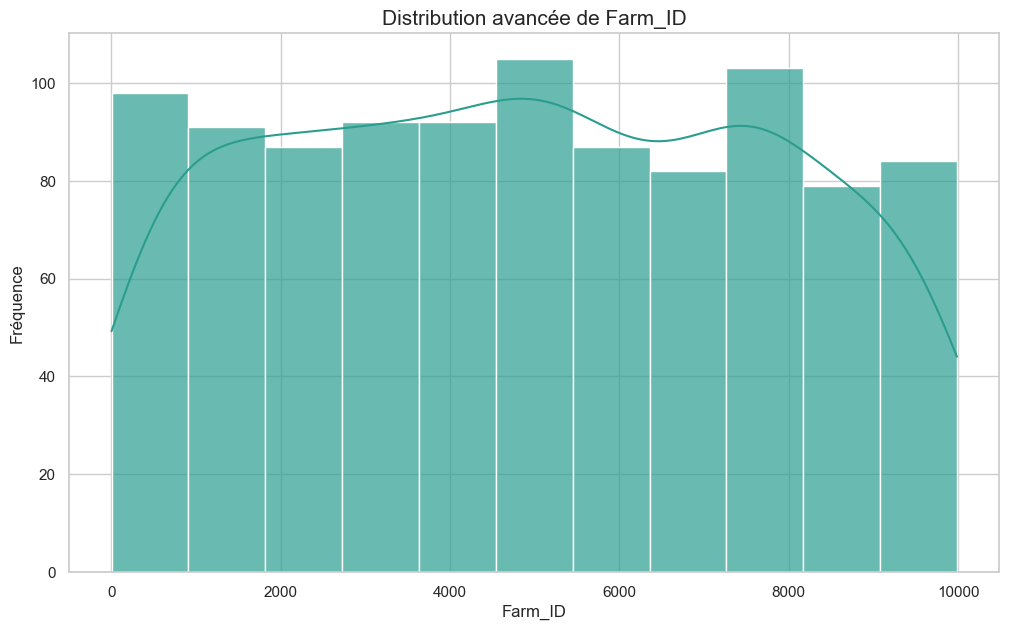

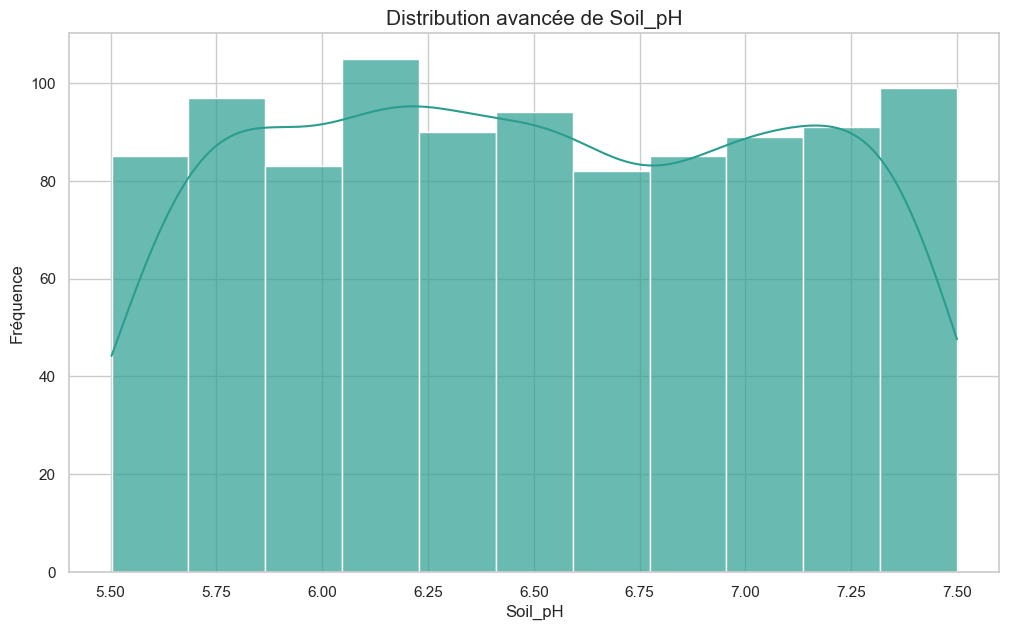

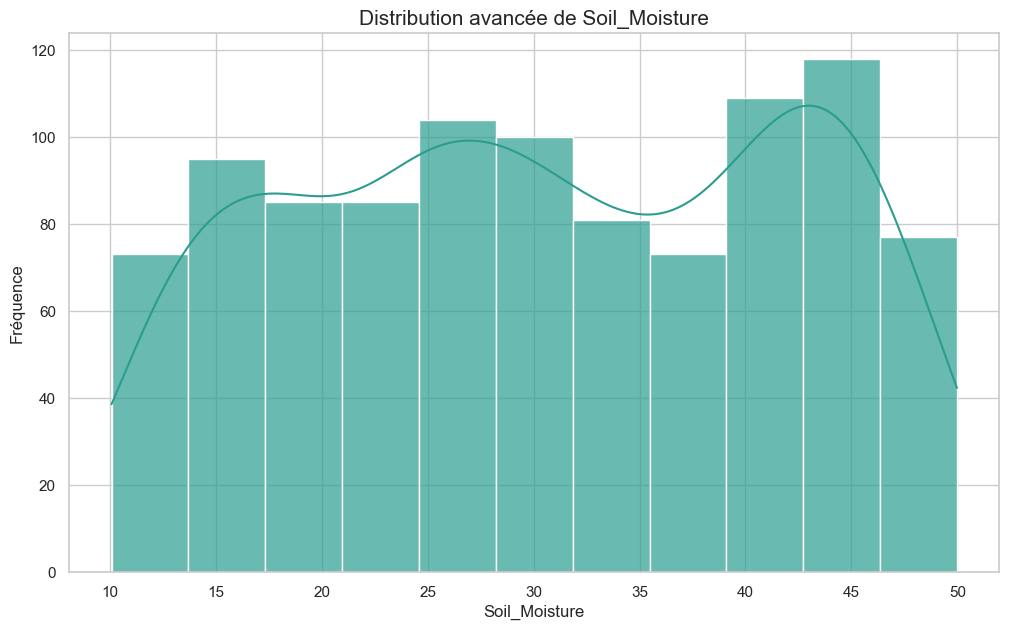

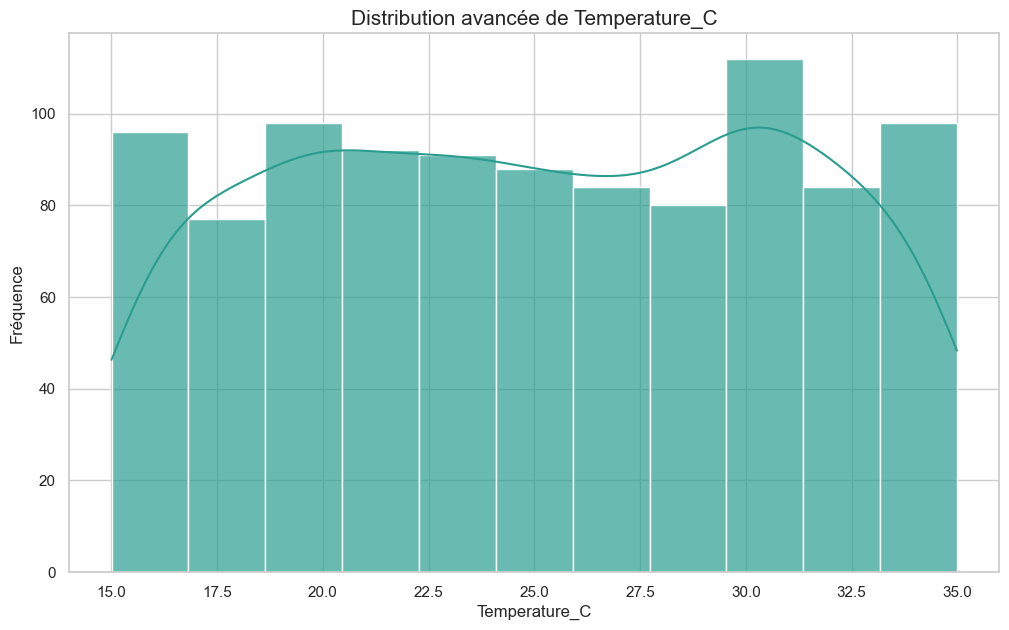

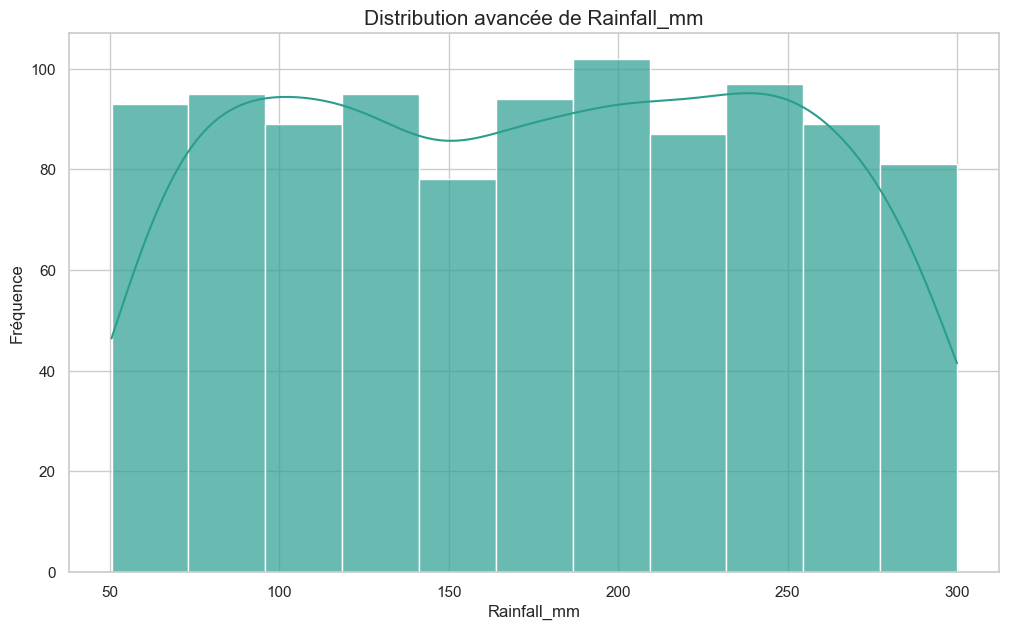

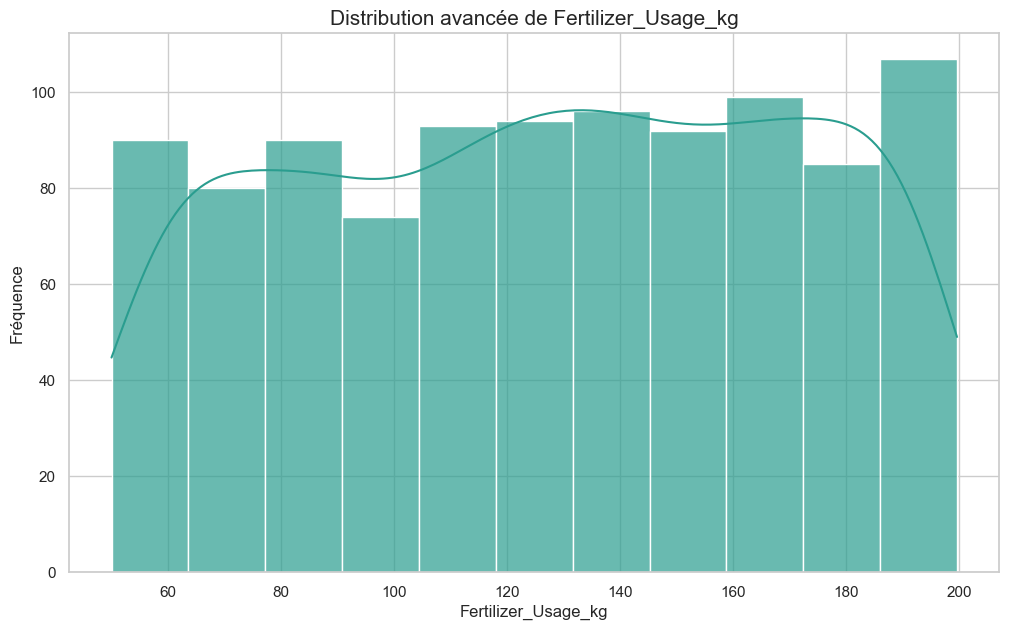

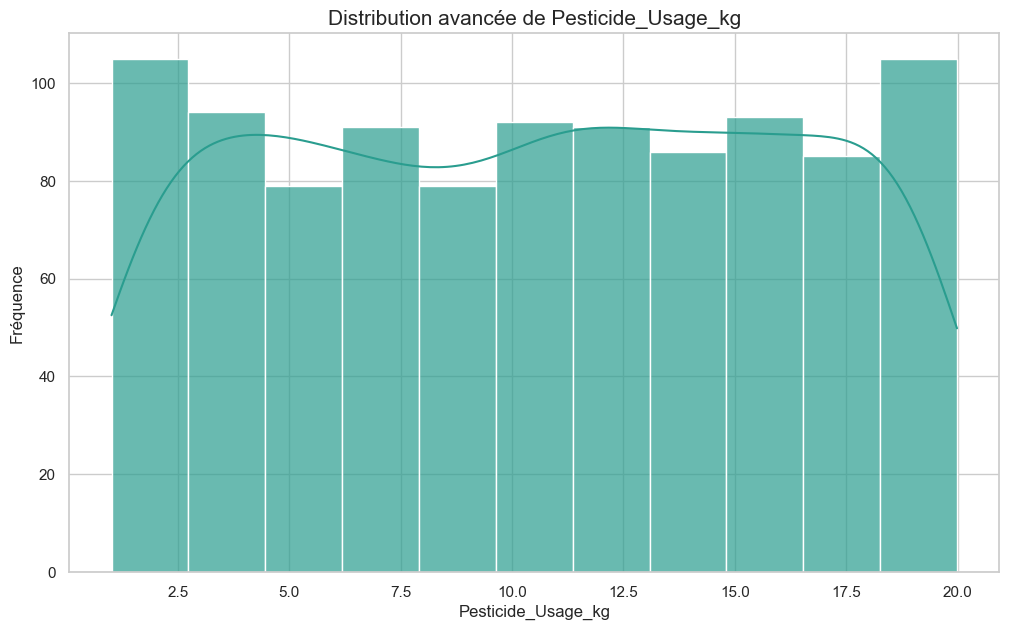

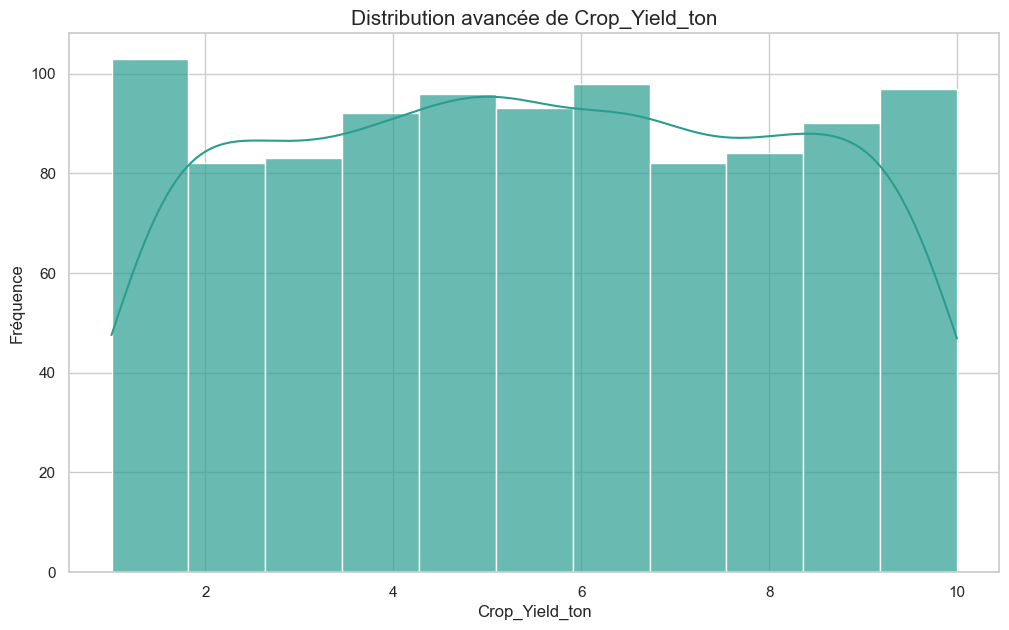

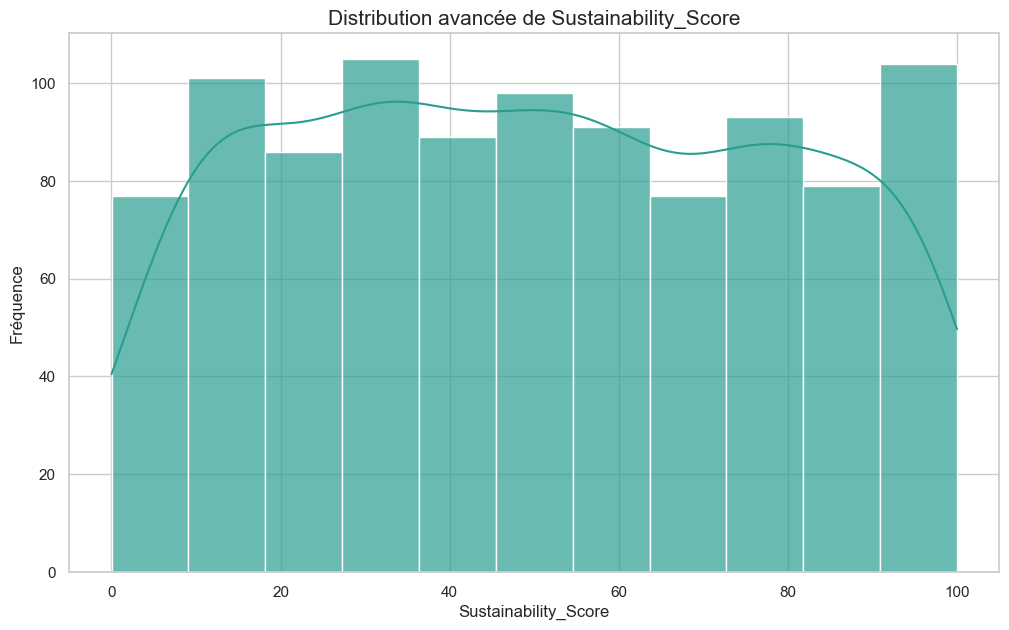

In [14]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, color="#2A9D8F", alpha=0.7)
    plt.title(f"Distribution avancée de {col}", fontsize=15)
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

C:\Users\merry b\AppData\Local\Temp\ipykernel_3712\1470253468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Crop_Type", y=col, palette=product_palette)


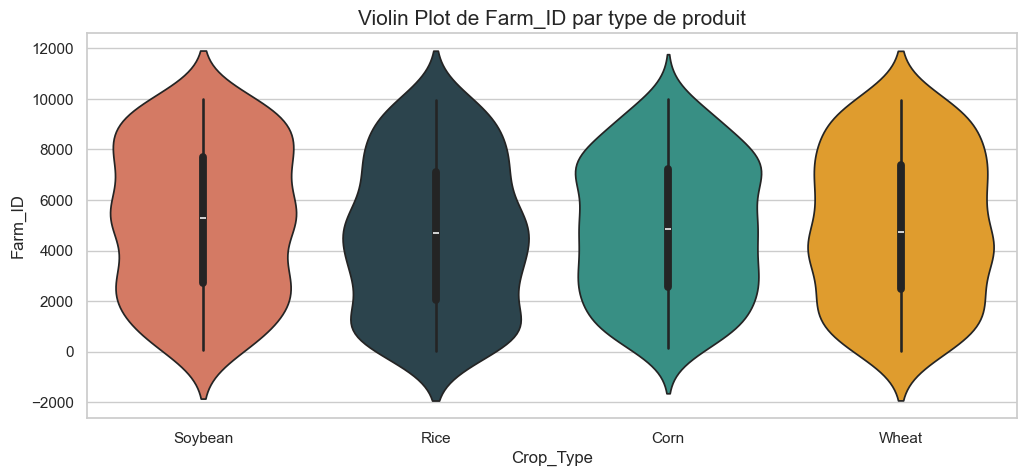

C:\Users\merry b\AppData\Local\Temp\ipykernel_3712\1470253468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Crop_Type", y=col, palette=product_palette)


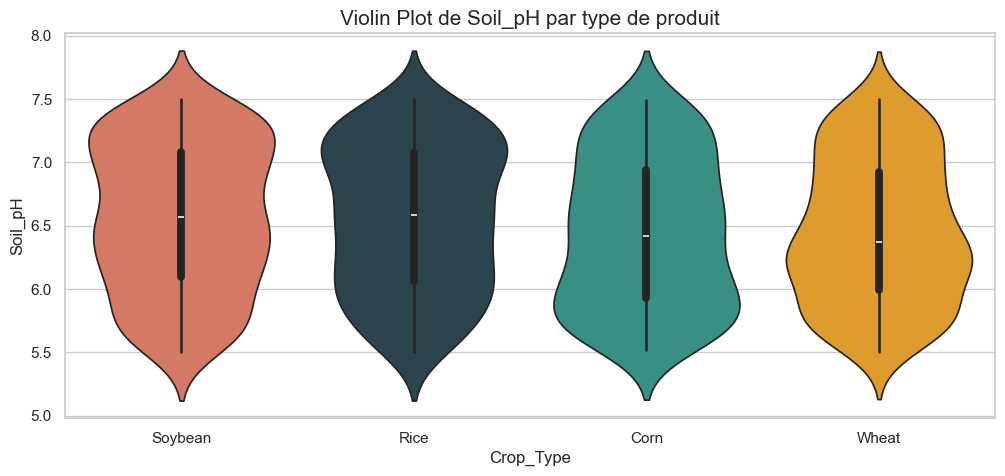

C:\Users\merry b\AppData\Local\Temp\ipykernel_3712\1470253468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Crop_Type", y=col, palette=product_palette)


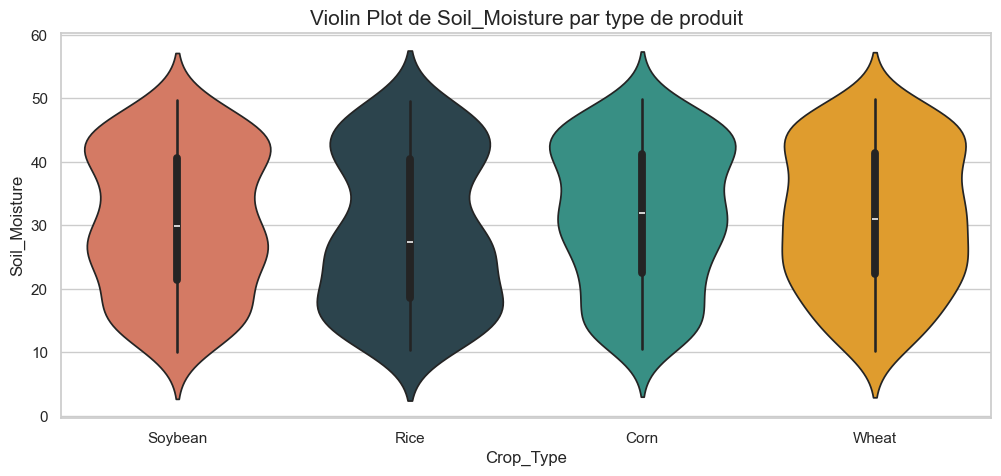

C:\Users\merry b\AppData\Local\Temp\ipykernel_3712\1470253468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Crop_Type", y=col, palette=product_palette)


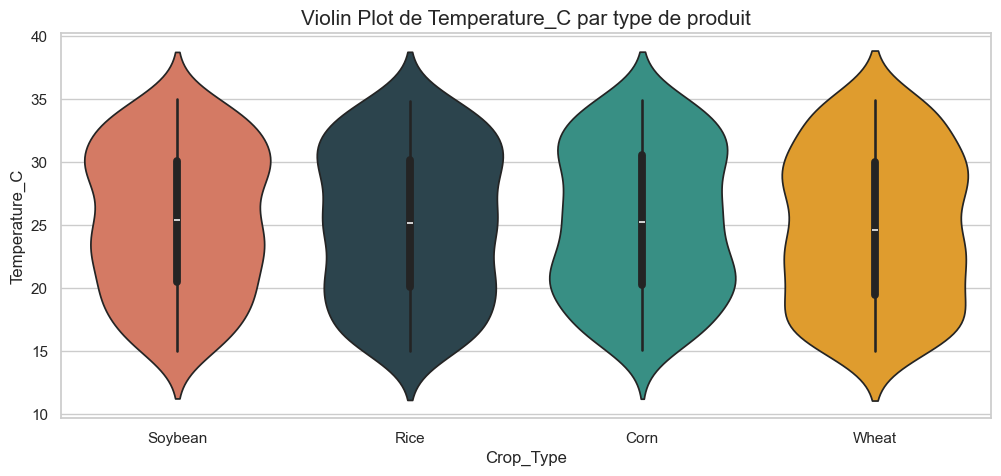

C:\Users\merry b\AppData\Local\Temp\ipykernel_3712\1470253468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Crop_Type", y=col, palette=product_palette)


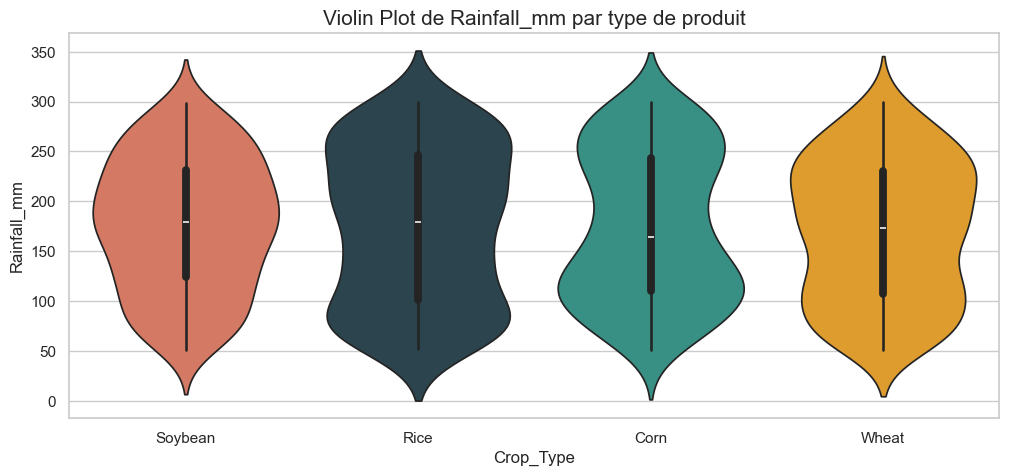

C:\Users\merry b\AppData\Local\Temp\ipykernel_3712\1470253468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Crop_Type", y=col, palette=product_palette)


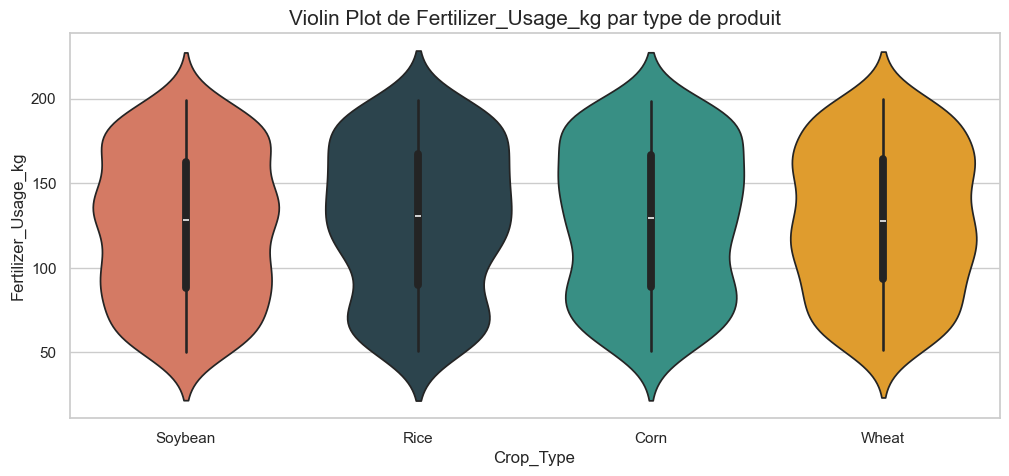

C:\Users\merry b\AppData\Local\Temp\ipykernel_3712\1470253468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Crop_Type", y=col, palette=product_palette)


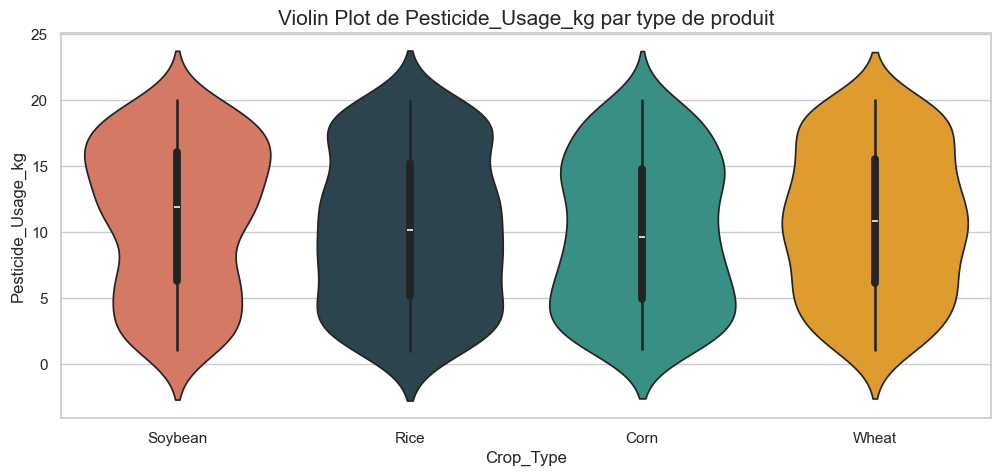

C:\Users\merry b\AppData\Local\Temp\ipykernel_3712\1470253468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Crop_Type", y=col, palette=product_palette)


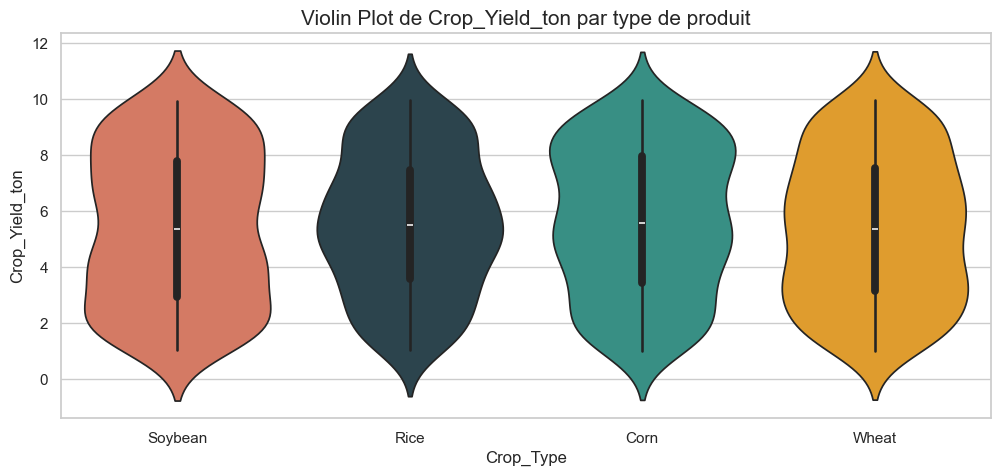

C:\Users\merry b\AppData\Local\Temp\ipykernel_3712\1470253468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Crop_Type", y=col, palette=product_palette)


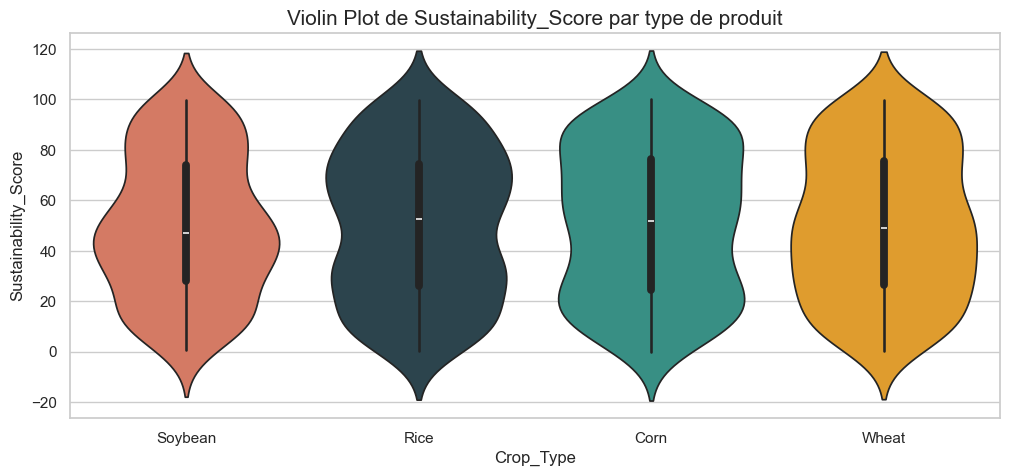

In [15]:
for col in numeric_cols:
    plt.figure(figsize=(12,5))
    sns.violinplot(data=df, x="Crop_Type", y=col, palette=product_palette)
    plt.title(f"Violin Plot de {col} par type de produit", fontsize=15)
    plt.show()

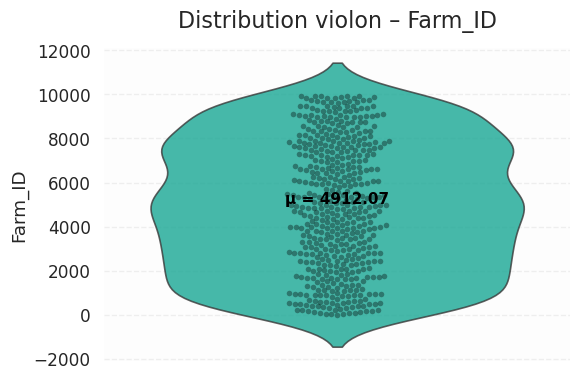

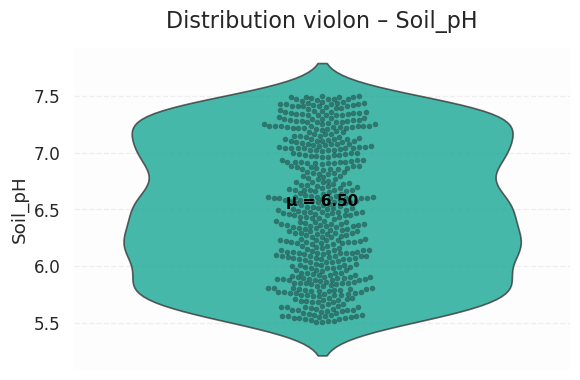

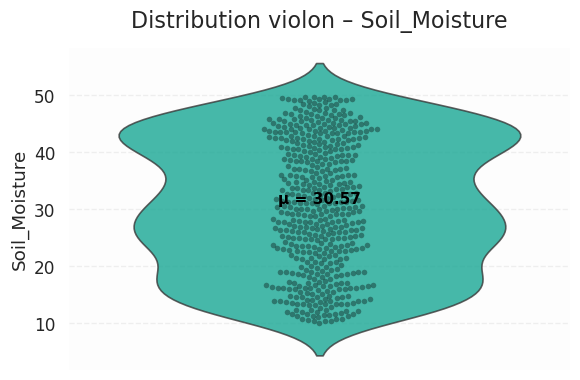

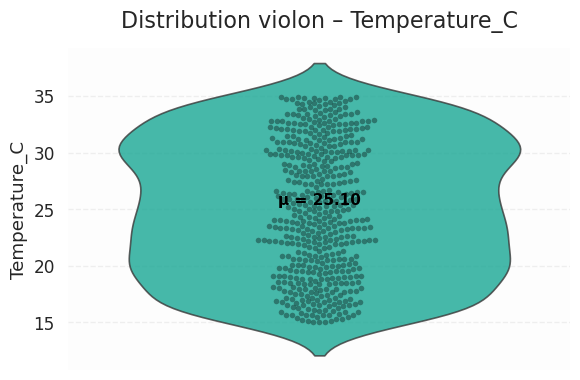

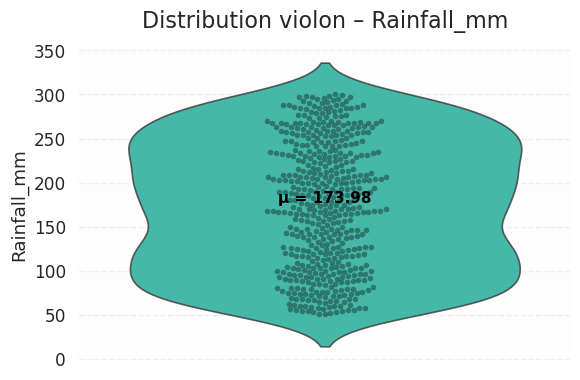

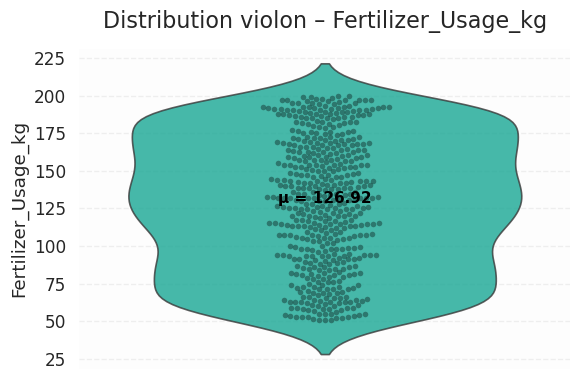

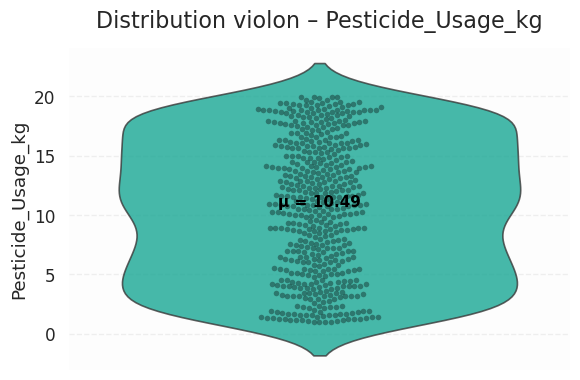

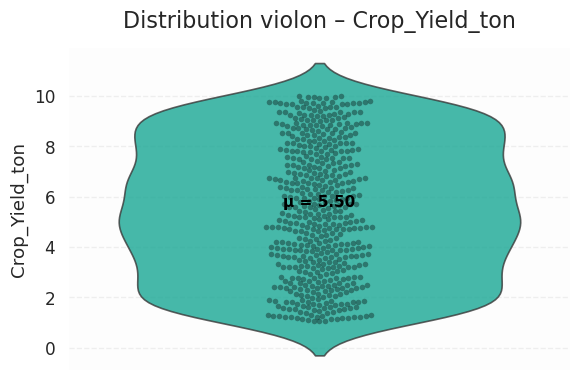

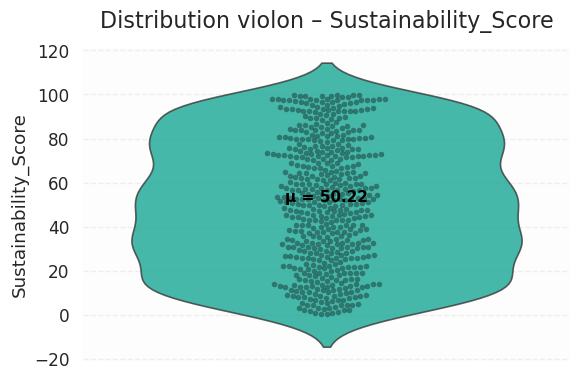

In [16]:
# Thème global professionnel
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.1)

# Palette premium
main_color = "#00BFA6"

# Boucle sur chaque colonne numérique
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    # --- VIOLIN PLOT ---
    sns.violinplot(
        data=df,
        y=col,
        color=main_color,
        inner=None,
        linewidth=1.2,
        alpha=0.8
    )

    # --- SWARM PLOT ---
    sns.swarmplot(
    data=df.sample(500, random_state=42),  # sample aléatoire
    y=col,
    color='black',
    alpha=0.35,
    size=4
    )

    # --- Moyenne ---
    mean_val = df[col].mean()
    plt.text(
        0, mean_val,
        f"µ = {mean_val:.2f}",
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='black'
    )

    # --- DESIGN PREMIUM ---
    plt.title(f"Distribution violon – {col}", fontsize=16, pad=15)
    plt.ylabel(col)
    plt.xlabel("")
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()

    # Fond dégradé subtil
    ax = plt.gca()
    ax.set_facecolor("#FDFDFD")
    ax.patch.set_alpha(0.9)

    # Suppression des bordures
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.show()

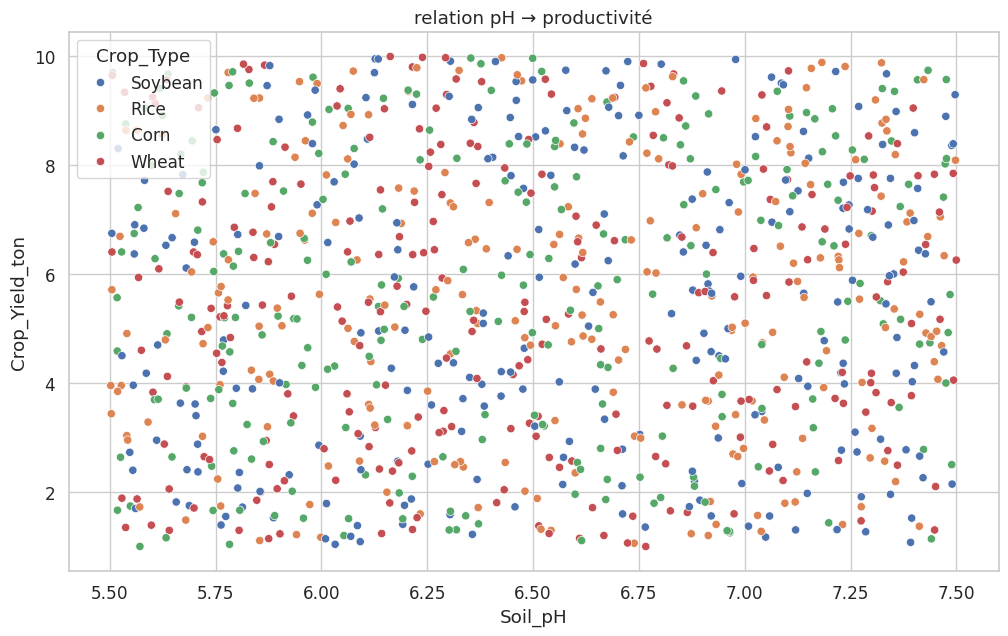

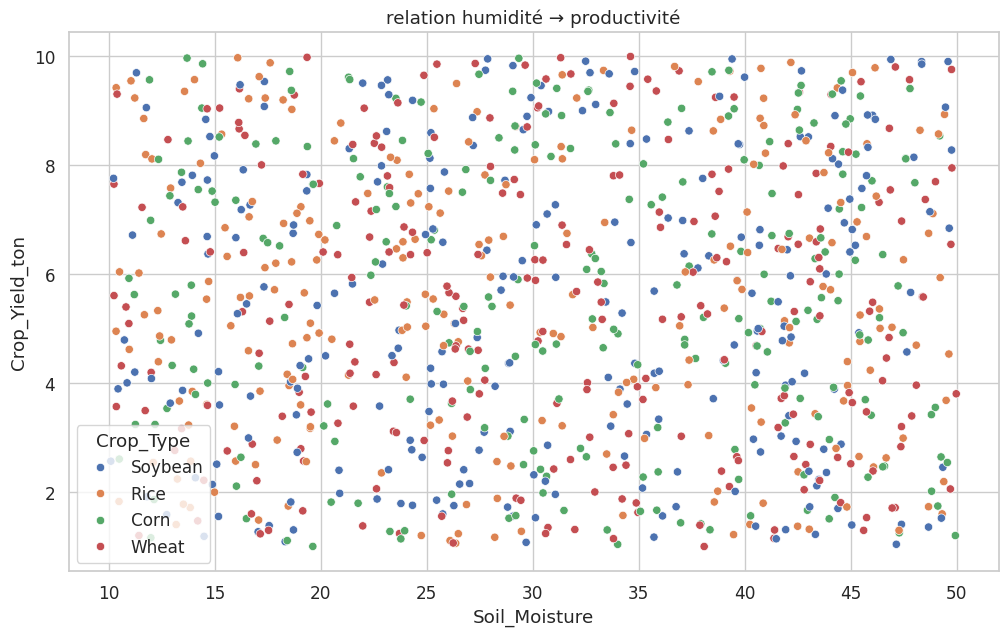

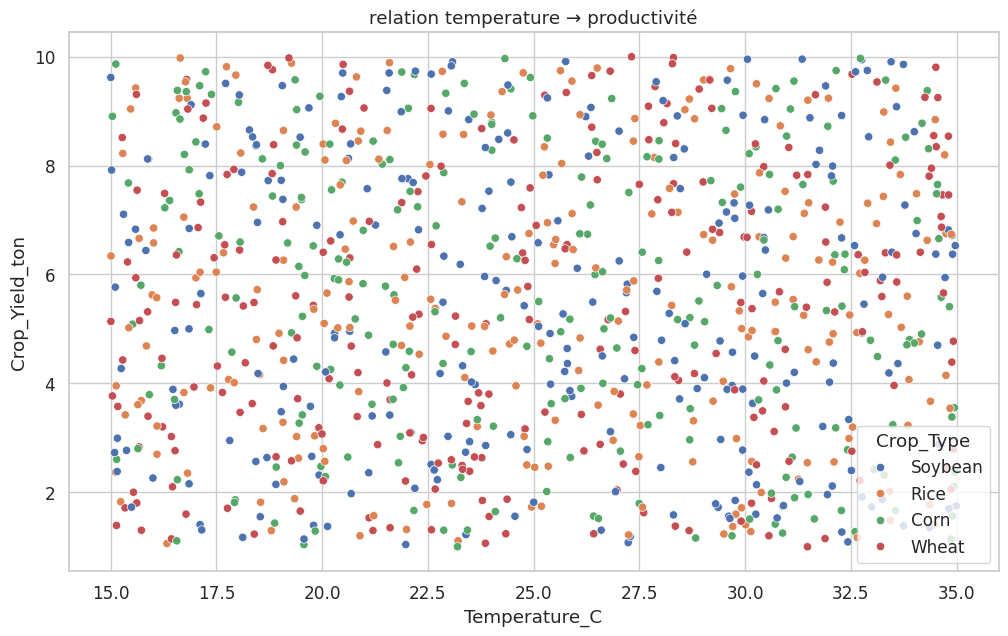

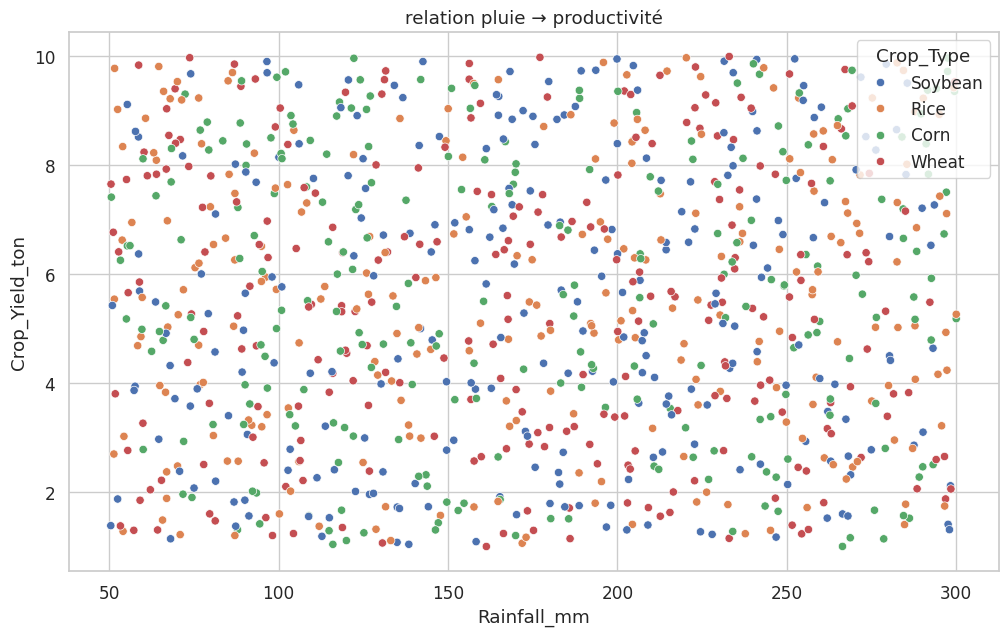

In [17]:

plt.figure()
sns.scatterplot(data=sample_stratified, x="Soil_pH", y="Crop_Yield_ton", hue="Crop_Type")
plt.title("relation pH → productivité")
plt.show()


plt.figure()
sns.scatterplot(data=sample_stratified, x="Soil_Moisture", y="Crop_Yield_ton", hue="Crop_Type")
plt.title("relation humidité → productivité")
plt.show()


plt.figure()
sns.scatterplot(data=sample_stratified, x="Temperature_C", y="Crop_Yield_ton", hue="Crop_Type")
plt.title("relation temperature → productivité")
plt.show()


plt.figure()
sns.scatterplot(data=sample_stratified, x="Rainfall_mm", y="Crop_Yield_ton", hue="Crop_Type")
plt.title("relation pluie → productivité")
plt.show()

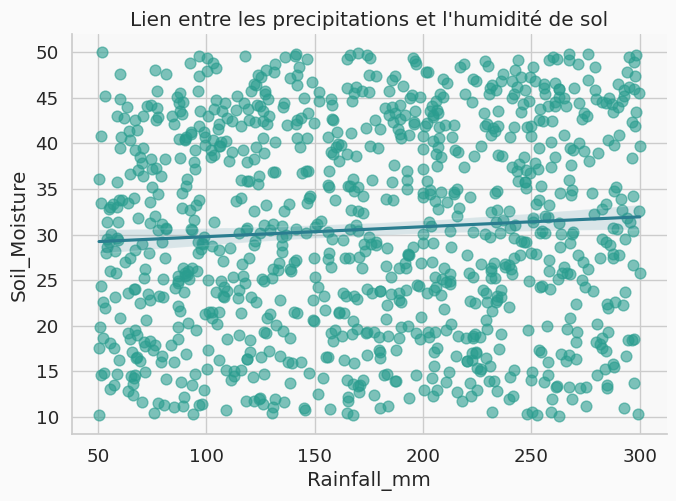

In [18]:
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.2)
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor'] = '#F8F8F8'
sns.lmplot(data=df, x='Rainfall_mm', y='Soil_Moisture', aspect=1.4, height=5, scatter_kws={'alpha':0.6, 's':60, 'color': "#2A9D8F"},  line_kws={'color': "#2A7D8F"})
plt.title("Lien entre les precipitations et l'humidité de sol")
plt.show()

C:\Users\merry b\AppData\Local\Temp\ipykernel_3712\4163833058.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


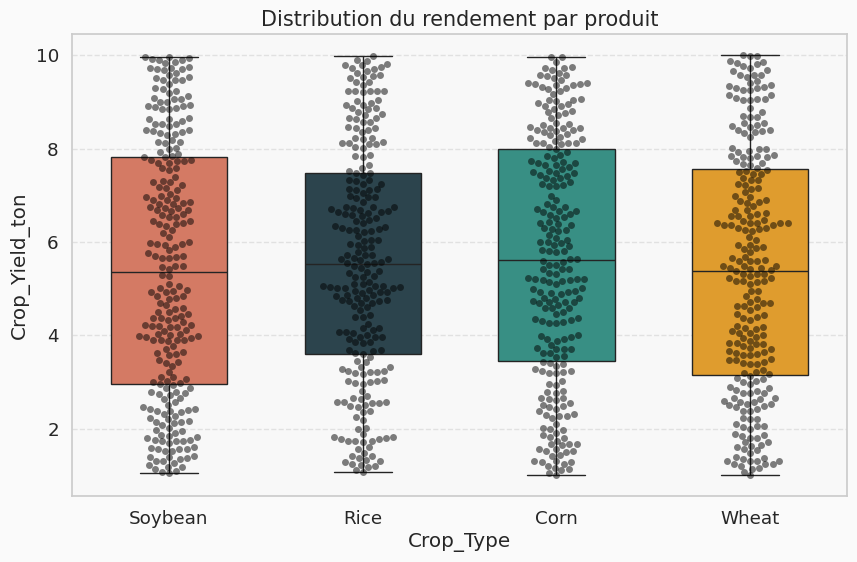

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Palette personnalisée par produit
product_palette = {
    "Wheat": "#FCA311",
    "Corn": "#2A9D8F",
    "Rice": "#264653",
    "Soybean": "#E76F51"
}

plt.figure(figsize=(10,6))
sns.boxplot(
    data=sample_stratified,
    x="Crop_Type",
    y="Crop_Yield_ton",
    palette=product_palette,
    width=0.6
)
sns.swarmplot(x='Crop_Type', y='Crop_Yield_ton', data=sample_stratified, color='black', alpha=0.5)
plt.title("Distribution du rendement par produit", fontsize=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

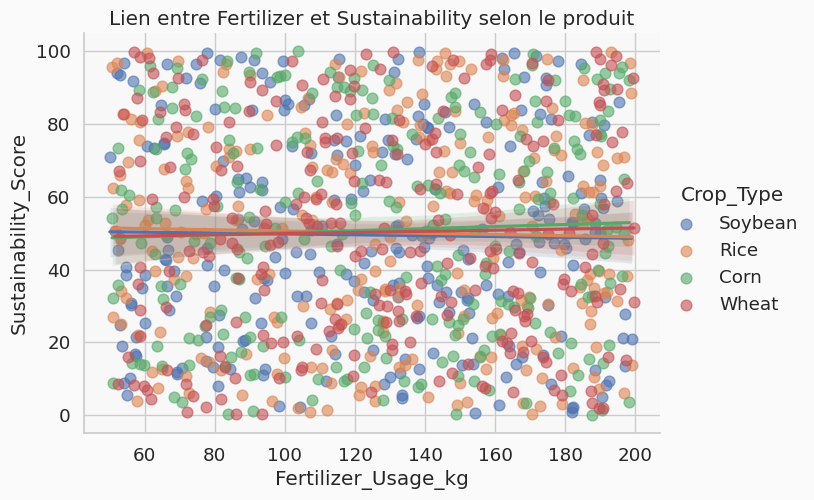

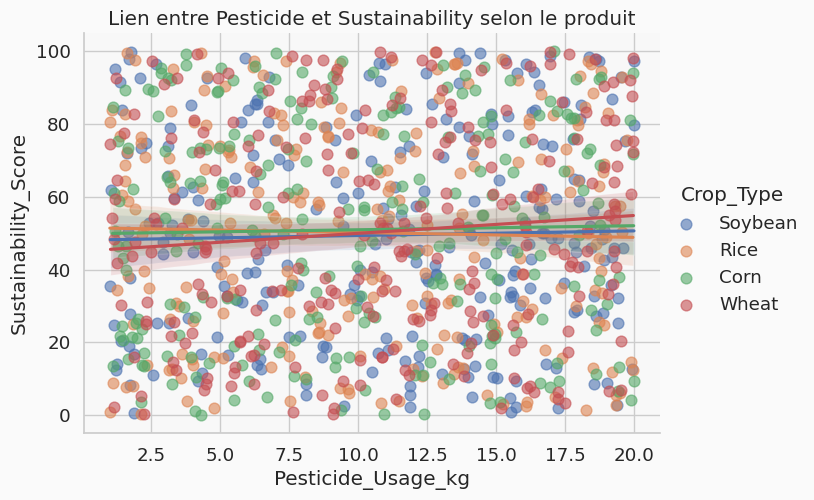

In [48]:
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.2)
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor'] = '#F8F8F8'
sns.lmplot(data=df, x='Fertilizer_Usage_kg', y='Sustainability_Score', hue='Crop_Type', aspect=1.4, height=5, scatter_kws={'alpha':0.6, 's':60})
plt.title("Lien entre Fertilizer et Sustainability selon le produit")
plt.show()

sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.2)
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor'] = '#F8F8F8'
sns.lmplot(data=df, x='Pesticide_Usage_kg', y='Sustainability_Score', hue='Crop_Type', aspect=1.4, height=5, scatter_kws={'alpha':0.6, 's':60})
plt.title("Lien entre Pesticide et Sustainability selon le produit")
plt.show()

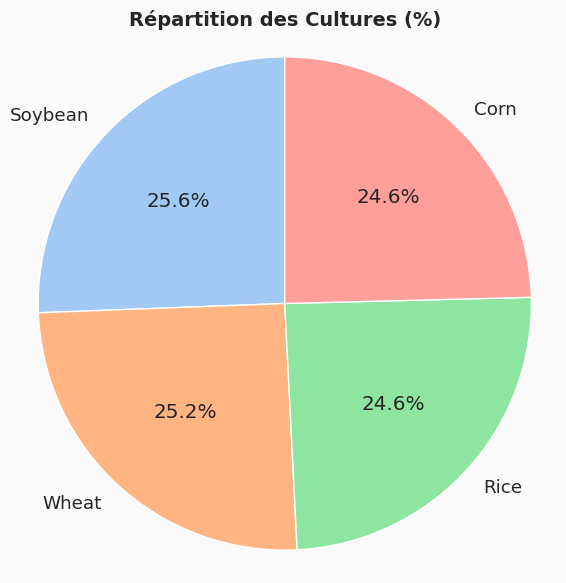

In [46]:
import matplotlib.pyplot as plt

# Compter le nombre de chaque produit
product_counts = df['Crop_Type'].value_counts()

palette = sns.color_palette("pastel")

# Création du graphique
plt.figure(figsize=(7, 7))

plt.pie(
    product_counts.values,
    labels=product_counts.index,
    autopct='%1.1f%%',   # afficher pourcentage
    startangle=90,
    colors=palette
)

plt.title("Répartition des Cultures (%)", fontsize=14, weight='bold')

plt.axis('equal')  # cercle parfait

plt.show()

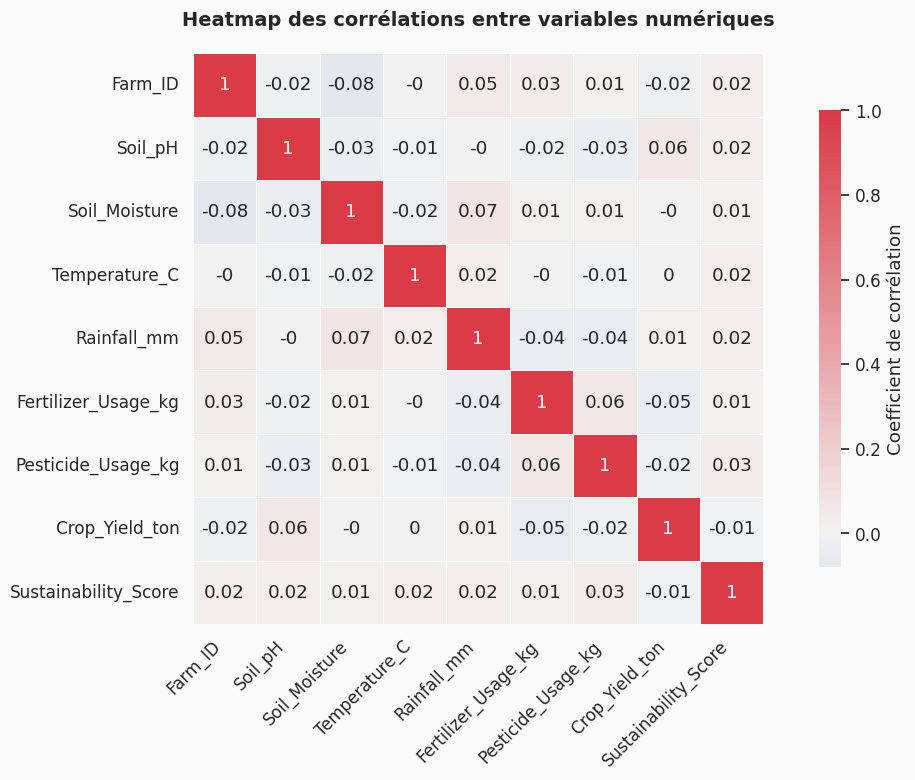

In [26]:
# Thème global cohérent
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.1)
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor'] = '#F8F9FA'

# Palette de corrélation douce et lisible
cmap = sns.diverging_palette(240, 10, as_cmap=True)

# Sélection des colonnes numériques (int + float)
num_cols = sample_stratified.select_dtypes(include=['int64', 'float64']).columns

# Calcul de la matrice de corrélation
corr = sample_stratified[num_cols].corr().round(2)

# Heatmap bien structurée
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,          # afficher les coefficients
    cmap=cmap,           # palette
    center=0,            # centrer autour de 0
    linewidths=0.6,      # séparateurs entre cases
    square=True,         # cases carrées
    cbar_kws={'shrink': 0.8, 'label': 'Coefficient de corrélation'}
)

plt.title("Heatmap des corrélations entre variables numériques", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()